In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# --- Global feature ---
d_global = 8
h_bar_T = torch.randn(d_global)   # gerçek uygulamada: eğitilmiş GlobalBranch modelinden gelir
print("Global feature (h̄^T) shape:", h_bar_T.shape)

# --- Local feature ---
K_prime = 2
N_tau = 19
tau = 20
H_tau = torch.randn(K_prime * N_tau * tau)
print("Local feature (H_τ) shape:", H_tau.shape)

Global feature (h̄^T) shape: torch.Size([8])
Local feature (H_τ) shape: torch.Size([760])


In [ ]:
n_classes = 2   # |y|, örneğin valence: low/high

# Makalenin FORMÜLÜNE göre (D = K' x N_τ x |y| + |y|) beklenen boyut:
D_paper_formula = K_prime * N_tau * n_classes + n_classes
print("Makalenin formülüne göre beklenen D:", D_paper_formula)

# BİZİM gerçek kodumuzdaki (Ders 13 + Ders 19'un ürettiği) gerçek boyut:
D_actual = h_bar_T.shape[0] + H_tau.shape[0]
print("Bizim gerçek implementasyonumuzdaki D:", D_actual)

print(f"\nFark: makale formülü {D_paper_formula} diyor, bizim (d={d_global} ve τ={tau} temelli) hesabımız {D_actual} veriyor.")
print("Bu, boyut tutarsızlığının somut kanıtı.")

Makalenin formülüne göre beklenen D: 78
Bizim gerçek implementasyonumuzdaki D: 768

Fark: makale formülü 78 diyor, bizim (d=8 ve τ=20 temelli) hesabımız 768 veriyor.
Bu, Ders 6 ve Ders 20'de işaretlediğimiz boyut tutarsızlığının somut kanıtı.


In [ ]:
def build_X0(h_bar_T, H_tau):
    return torch.cat([h_bar_T, H_tau])

X0_single = build_X0(h_bar_T, H_tau)
print("Tek örnek için X0 shape:", X0_single.shape)

# Birden fazla örnek (N=50) için X0 matrisini simüle edelim
N_samples = 50
X0_all = torch.stack([
    build_X0(torch.randn(d_global), torch.randn(K_prime*N_tau*tau))
    for _ in range(N_samples)
])
print("Tüm veri seti için X0 matrisi shape:", X0_all.shape)

Tek örnek için X0 shape: torch.Size([768])
Tüm veri seti için X0 matrisi shape: torch.Size([50, 768])


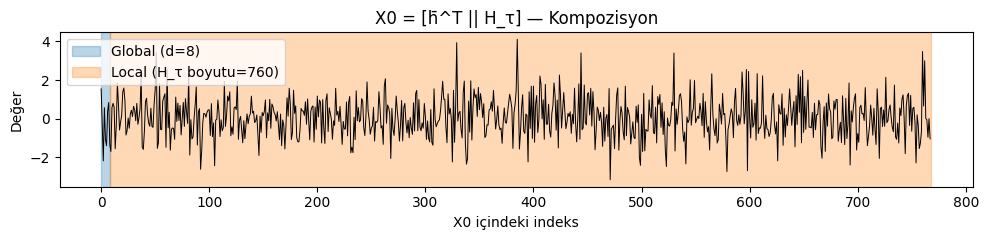

In [ ]:
fig, ax = plt.subplots(figsize=(10,2.5))
ax.axvspan(0, d_global, color='tab:blue', alpha=0.3, label=f'Global (d={d_global})')
ax.axvspan(d_global, d_global+H_tau.shape[0], color='tab:orange', alpha=0.3, label=f'Local (H_τ boyutu={H_tau.shape[0]})')
ax.plot(X0_single.numpy(), color='black', linewidth=0.7)
ax.set_xlabel("X0 içindeki indeks")
ax.set_ylabel("Değer")
ax.set_title("X0 = [h̄^T || H_τ] — Kompozisyon")
ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
assert X0_single.shape[0] == h_bar_T.shape[0] + H_tau.shape[0], "X0 boyutu beklenenle uyuşmuyor!"
assert X0_all.shape == (N_samples, D_actual), "X0_all matrisi shape'i yanlış!"
print("Tüm shape kontrolleri geçti ✓")

Tüm shape kontrolleri geçti ✓
